In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from src.risk_index import normalize_components, compute_final_risk_index, get_top_risk_objects
from src.data_loader import load_neo_data
from src.feature_engineering import build_features
from src.anomaly_model import (
    fit_isolation_forest,
    add_anomaly_scores,
    get_top_anomalies
)
from src.supervised_model import (
    train_hazard_model,
    evaluate_hazard_model,
    add_hazard_probability,
    get_coefficient_table
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
# Load + build features
df = load_neo_data()
df = build_features(df)

In [15]:
# Features for anomaly detection
anomaly_features = [
    "log_velocity",
    "log_miss_distance",
    "diameter_mid",
    "kinetic_proxy",
    "absolute_magnitude",
    "risk_score"
]

iso_model = fit_isolation_forest(df, anomaly_features)
df = add_anomaly_scores(df, iso_model, anomaly_features)

top20 = get_top_anomalies(df, n=20)
top20


In [ ]:
# Supervised model
supervised_features = [
    "log_velocity",
    "log_miss_distance",
    "diameter_mid",
    "absolute_magnitude",
    "kinetic_proxy"
]

model, X_test, y_test, y_pred, y_prob = train_hazard_model(df, supervised_features)
metrics = evaluate_hazard_model(y_test, y_pred, y_prob)
metrics

In [ ]:
df = add_hazard_probability(df, model, supervised_features)

In [ ]:
df = normalize_components(df)
df = compute_final_risk_index(df)

df = normalize_components(df)
df = compute_final_risk_index(df)

In [ ]:
coef_table = get_coefficient_table(model, supervised_features)
coef_table

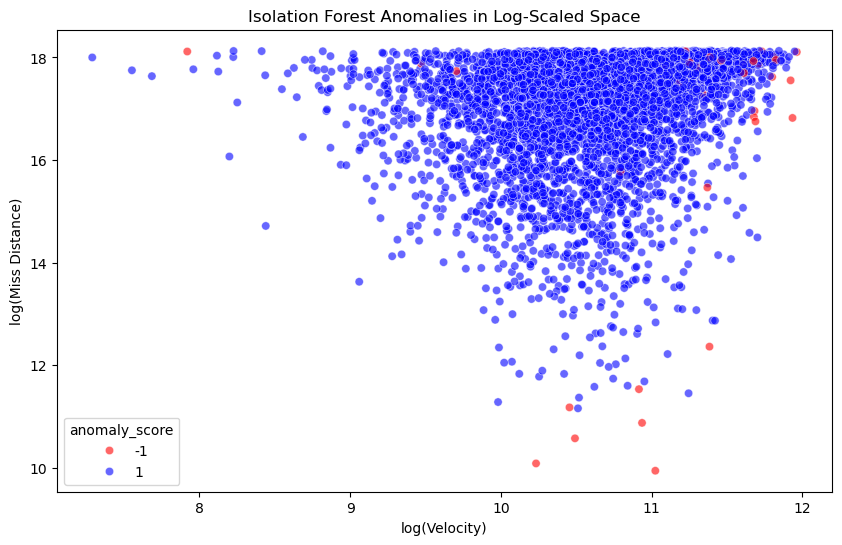

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='log_velocity',
    y='log_miss_distance',
    hue='anomaly_score',
    palette={1: 'blue', -1: 'red'},
    alpha=0.6
)
plt.title("Isolation Forest Anomalies in Log-Scaled Space")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")
plt.show()


In [17]:
# rank the anomalies
# Sort by anomaly_value (lower = more anomalous)
top20 = df.sort_values('anomaly_value').head(20)

top20[['id', 'name', 'relative_velocity', 'miss_distance', 
               'diameter_mid', 'absolute_magnitude', 
               'risk_score', 'anomaly_value']]


,id,name,relative_velocity,miss_distance,diameter_mid,absolute_magnitude,risk_score,anomaly_value
12709,2000433,433 Eros (A898 PA),15884.252623,5.468808e+07,37.285727,10.31,-5.688957,-0.132463
36418,2001036,1036 Ganymed (A924 UB),51496.923293,5.372124e+07,61.311595,9.23,-2.714256,-0.131729
37651,2000433,433 Eros (A898 PA),21402.705247,2.672952e+07,37.285727,10.31,-5.243747,-0.129998
56533,2000433,433 Eros (A898 PA),21761.703426,3.120592e+07,37.285727,10.31,-5.315489,-0.128009
22026,2003200,3200 Phaethon (1983 TB),134806.935530,1.808573e+07,5.669472,14.40,-6.416623,-0.122365
60218,2002212,2212 Hephaistos (1978 SB),135956.251475,4.478821e+07,8.463356,13.53,-6.572469,-0.120187
50832,2003200,3200 Phaethon (1983 TB),114797.864507,1.031203e+07,5.669472,14.40,-6.452150,-0.118406
4445,2016960,16960 (1998 QS52),149936.050762,5.424840e+07,5.565993,14.44,-6.736937,-0.116522
16895,2001866,1866 Sisyphus (1972 XA),96530.774890,7.402691e+07,13.981141,12.44,-6.895425,-0.115895
87849,2005143,5143 Heracles (1991 VL),122333.637277,4.581021e+07,6.420112,14.13,-7.003509,-0.111809


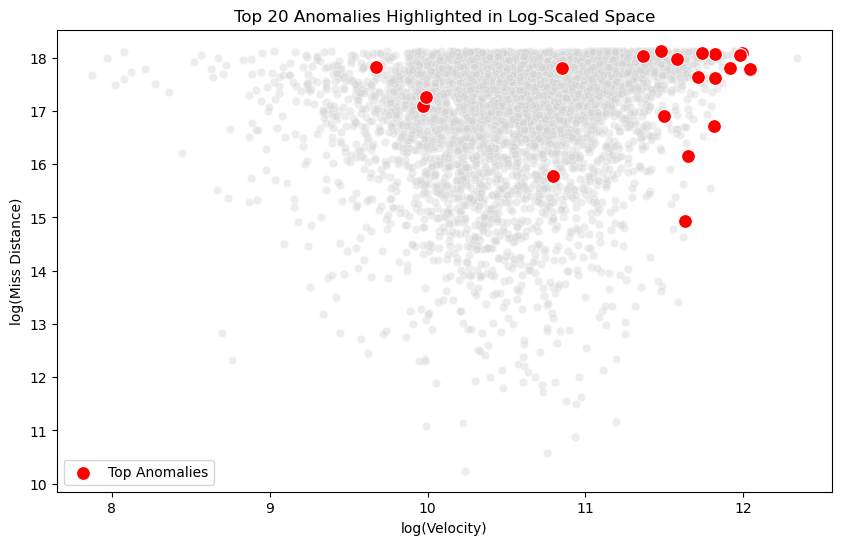

In [18]:
# visualize top anomalies
subset = top20

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='log_velocity',
    y='log_miss_distance',
    color='lightgray',
    alpha=0.4
)

sns.scatterplot(
    data=subset,
    x='log_velocity',
    y='log_miss_distance',
    color='red',
    s=100,
    label='Top Anomalies'
)

plt.title("Top 20 Anomalies Highlighted in Log-Scaled Space")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")
plt.legend()
plt.show()


In [19]:
top_anomalies[['id', 'name', 
               'relative_velocity', 
               'miss_distance', 
               'diameter_mid', 
               'absolute_magnitude', 
               'risk_score', 
               'anomaly_value',
               'hazardous']]

,id,name,relative_velocity,miss_distance,diameter_mid,absolute_magnitude,risk_score,anomaly_value,hazardous
12709,2000433,433 Eros (A898 PA),15884.252623,5.468808e+07,37.285727,10.31,-5.688957,-0.132463,False
36418,2001036,1036 Ganymed (A924 UB),51496.923293,5.372124e+07,61.311595,9.23,-2.714256,-0.131729,False
37651,2000433,433 Eros (A898 PA),21402.705247,2.672952e+07,37.285727,10.31,-5.243747,-0.129998,False
56533,2000433,433 Eros (A898 PA),21761.703426,3.120592e+07,37.285727,10.31,-5.315489,-0.128009,False
22026,2003200,3200 Phaethon (1983 TB),134806.935530,1.808573e+07,5.669472,14.40,-6.416623,-0.122365,True
60218,2002212,2212 Hephaistos (1978 SB),135956.251475,4.478821e+07,8.463356,13.53,-6.572469,-0.120187,False
50832,2003200,3200 Phaethon (1983 TB),114797.864507,1.031203e+07,5.669472,14.40,-6.452150,-0.118406,True
4445,2016960,16960 (1998 QS52),149936.050762,5.424840e+07,5.565993,14.44,-6.736937,-0.116522,True
16895,2001866,1866 Sisyphus (1972 XA),96530.774890,7.402691e+07,13.981141,12.44,-6.895425,-0.115895,False
87849,2005143,5143 Heracles (1991 VL),122333.637277,4.581021e+07,6.420112,14.13,-7.003509,-0.111809,False


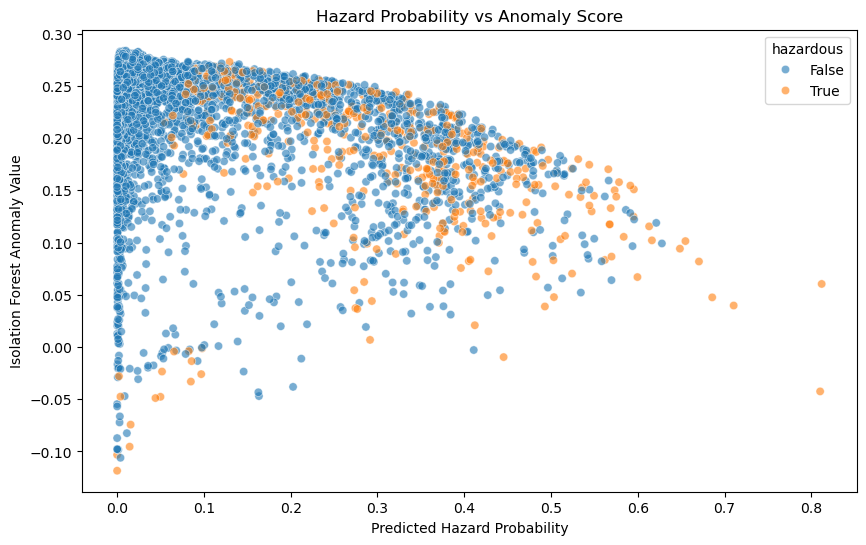

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='hazard_probability',
    y='anomaly_value',
    hue='hazardous',
    alpha=0.6
)
plt.title("Hazard Probability vs Anomaly Score")
plt.xlabel("Predicted Hazard Probability")
plt.ylabel("Isolation Forest Anomaly Value")
plt.show()


In [ ]:
scaler = MinMaxScaler()

df['norm_hazard_prob'] = scaler.fit_transform(df[['hazard_probability']])
df['norm_anomaly'] = scaler.fit_transform(df[['anomaly_value']])
df['norm_risk_score'] = scaler.fit_transform(df[['risk_score']])


In [25]:
df['final_risk_index'] = (
    0.5 * df['norm_hazard_prob'] +     # supervised
    0.3 * (1 - df['norm_anomaly']) +   # unsupervised (invert: lower anomaly_value = riskier)
    0.2 * df['norm_risk_score']        # engineered
)

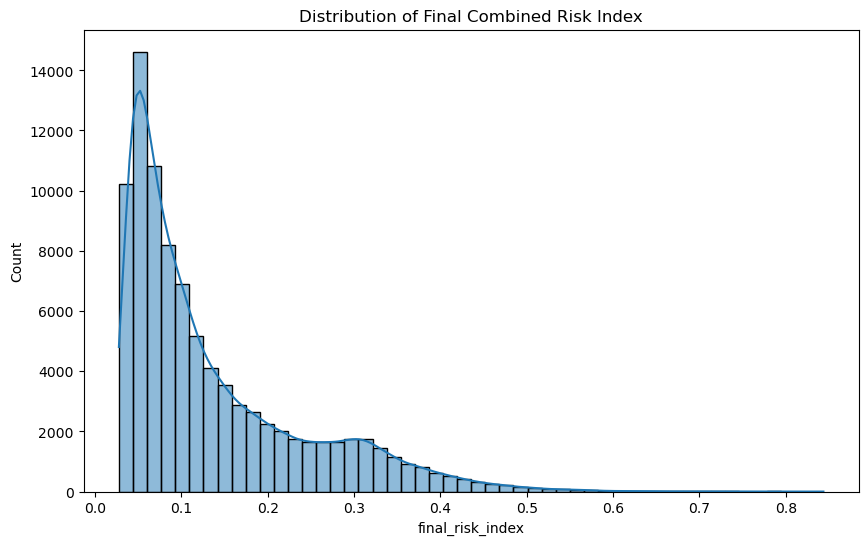

In [26]:
# distribution of risk index
plt.figure(figsize=(10,6))
sns.histplot(df['final_risk_index'], bins=50, kde=True)
plt.title("Distribution of Final Combined Risk Index")
plt.show()

In [27]:
# Top 20 highest-risk objects
df.sort_values('final_risk_index', ascending=False).head(20)[[
    'id', 'name', 'relative_velocity', 'miss_distance',
    'diameter_mid', 'absolute_magnitude',
    'hazard_probability', 'anomaly_value',
    'final_risk_index', 'hazardous'
]]


,id,name,relative_velocity,miss_distance,diameter_mid,absolute_magnitude,hazard_probability,anomaly_value,final_risk_index,hazardous
69807,3729835,(2015 TB145),125807.719190,4.868071e+05,0.422224,20.04,0.913719,-0.020813,0.843622,True
4802,3131063,(2002 NY40),75226.687788,5.269744e+05,0.681620,19.00,0.920658,-0.002282,0.811077,True
17142,3263453,(2004 XP14),62664.322585,4.324384e+05,0.566947,19.40,0.917746,0.007651,0.799217,True
2472,3789399,(2017 VW13),40792.770407,1.432727e+05,0.311561,20.70,0.897687,0.016398,0.787159,True
17150,2612901,612901 (2004 XP14),62664.322601,4.324384e+05,0.471566,19.80,0.905233,0.017352,0.785187,True
47388,3670721,(2014 JO25),120810.256121,1.758044e+06,1.184521,17.80,0.810027,-0.042477,0.784626,True
83570,2231937,231937 (2001 FO32),123887.394193,2.016392e+06,1.310819,17.58,0.762049,-0.048903,0.762978,True
465,3070541,(2001 EC),80976.423144,1.471204e+06,0.800834,18.65,0.864574,0.010624,0.759744,True
2988,3102719,(2001 YB5),110118.237589,8.321449e+05,0.284147,20.90,0.810437,0.008639,0.751396,True
61926,2388188,388188 (2006 DP14),97683.599040,2.398364e+06,0.672268,19.03,0.832980,0.021470,0.734997,True


In [ ]:
df.to_csv("../data/processed/neo_model_outputs.csv", index=False)